<a href="https://colab.research.google.com/github/PKCO/IMAGE-SHARPENING/blob/main/Image_Sharpening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Datasets that ive downloaded from kaggle**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("soumikrakshit/div2k-high-resolution-images")

print("Path to dataset files:", path)

100%|██████████| 3.71G/3.71G [00:37<00:00, 105MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/soumikrakshit/div2k-high-resolution-images/versions/1


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hliang001/flickr2k")

print("Path to dataset files:", path)

100%|██████████| 20.0G/20.0G [03:07<00:00, 115MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hliang001/flickr2k/versions/1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")

print("Path to dataset files:", path)

100%|██████████| 56.0M/56.0M [00:00<00:00, 159MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/versions/1


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/celeba-dataset


**Code for image classification**

Subdirectories in dataset directory: ['img_align_celeba']
Starting training...
Epoch [1/5], Loss: 0.2616
Epoch [2/5], Loss: 0.1024
Epoch [3/5], Loss: 0.0716
Epoch [4/5], Loss: 0.0598
Epoch [5/5], Loss: 0.0500
Training completed.


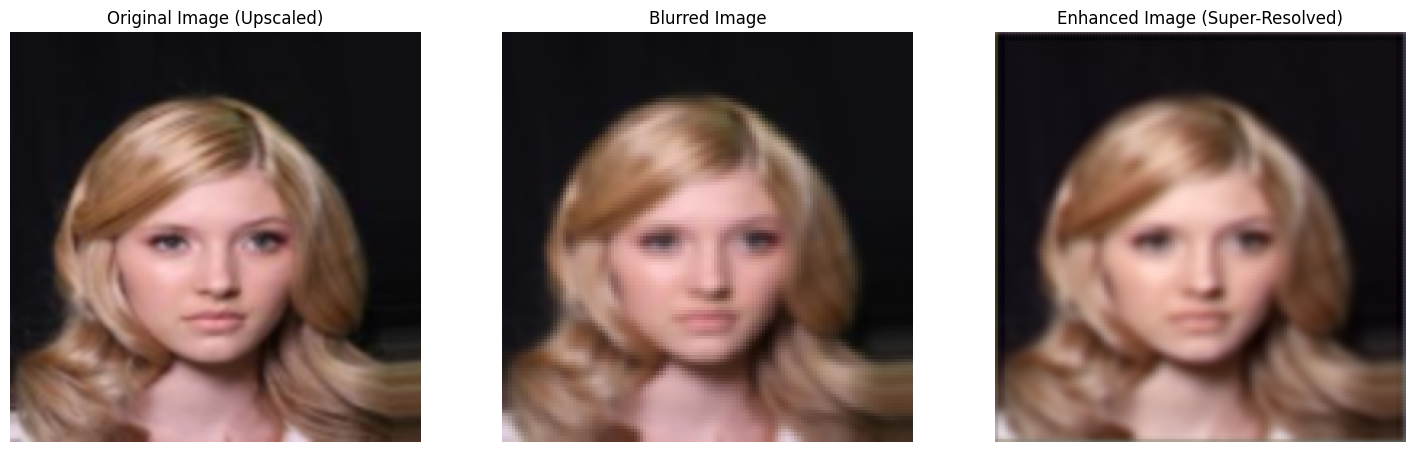

In [ ]:
!pip install opencv-python-headless

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path to CelebA dataset (after downloading)
celeba_data_path = "/kaggle/input/celeba-dataset/img_align_celeba"

print("Subdirectories in dataset directory:", os.listdir(celeba_data_path))

# Define image transformations with normalization to [-1,1]
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1,1]
])

# Custom dataset for CelebA
class CelebADataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None, limit_images=100):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if file.endswith('.jpg'):
                    self.image_paths.append(os.path.join(root, file))
        self.image_paths = self.image_paths[:limit_images]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)  # normalized tensor [-1,1]

        # Convert to numpy for Gaussian blur (convert back to [0,1] for cv2)
        image_np = (image * 0.5 + 0.5).permute(1, 2, 0).numpy()  # [H,W,C], range [0,1]
        blurred_np = cv2.GaussianBlur(image_np, (5, 5), 0)

        # Convert blurred image back to tensor normalized [-1,1]
        blurred_tensor = torch.tensor(blurred_np).permute(2, 0, 1)  # [C,H,W]
        blurred_tensor = (blurred_tensor - 0.5) / 0.5  # normalize to [-1,1]

        return image, blurred_tensor

# DataLoader
celeba_dataset = CelebADataset(celeba_data_path, transform, limit_images=200)
train_dataloader = DataLoader(celeba_dataset, batch_size=16, shuffle=True)

# Enhanced super-resolution model with PixelShuffle
class EnhancedUpscaleModel(nn.Module):
    def __init__(self):
        super(EnhancedUpscaleModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 3 * 4, kernel_size=3, padding=1)  # 3 channels * 2^2 for PixelShuffle
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor=2)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pixel_shuffle(self.conv3(x))
        return x

# Initialize model and device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EnhancedUpscaleModel().to(device)

# Optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.L1Loss()

# Training loop (few epochs for demonstration)
num_epochs = 5
print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for real_images, blurred_images in train_dataloader:
        real_images = real_images.to(device)
        blurred_images = blurred_images.to(device)

        optimizer.zero_grad()

        # Forward pass: super-resolve blurred images
        outputs = model(blurred_images)

        # Resize real_images to match output size (outputs are 256x256)
        real_images_upscaled = nn.functional.interpolate(real_images, scale_factor=2, mode='bilinear', align_corners=False)

        loss = criterion(outputs, real_images_upscaled)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("Training completed.")

# Function to denormalize and convert tensor to numpy image for visualization
def tensor_to_image(tensor):
    tensor = tensor.cpu().detach()
    tensor = tensor * 0.5 + 0.5  # Denormalize to [0,1]
    tensor = torch.clamp(tensor, 0, 1)
    img = tensor.numpy().transpose(1, 2, 0)  # C,H,W -> H,W,C
    return img

# Display sample images after training
def display_sample_images(dataloader):
    model.eval()
    with torch.no_grad():
        for real_images, blurred_images in dataloader:
            real_images = real_images.to(device)
            blurred_images = blurred_images.to(device)

            enhanced_images = model(blurred_images)

            # Upscale real images for comparison
            real_images_upscaled = nn.functional.interpolate(real_images, scale_factor=2, mode='bilinear', align_corners=False)

            # Convert to numpy images for matplotlib
            real_img = tensor_to_image(real_images_upscaled[0])
            blurred_img = tensor_to_image(blurred_images[0])
            enhanced_img = tensor_to_image(enhanced_images[0])

            fig, axs = plt.subplots(1, 3, figsize=(18, 6))

            axs[0].imshow(real_img)
            axs[0].set_title('Original Image (Upscaled)')
            axs[0].axis('off')

            axs[1].imshow(blurred_img)
            axs[1].set_title('Blurred Image')
            axs[1].axis('off')

            axs[2].imshow(enhanced_img)
            axs[2].set_title('Enhanced Image (Super-Resolved)')
            axs[2].axis('off')

            plt.show()
            break

# Show results
display_sample_images(train_dataloader)


Subdirectories in dataset directory: ['img_align_celeba']


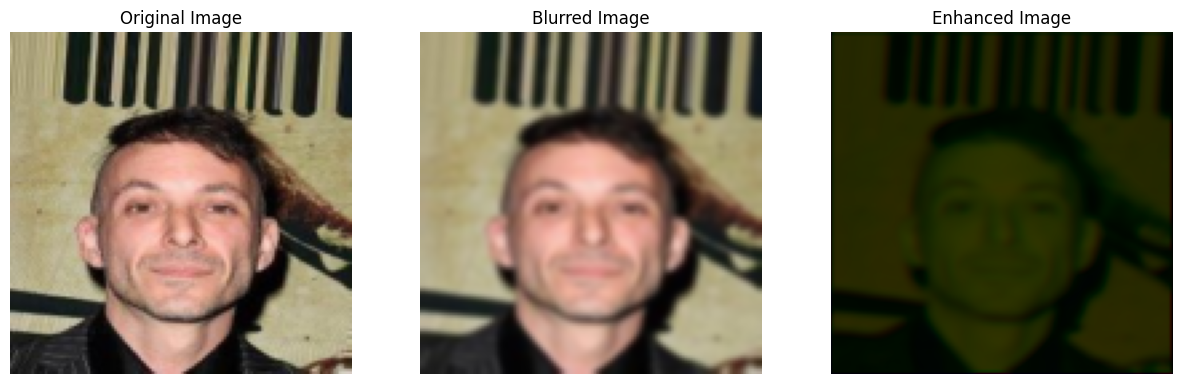

In [ ]:
!pip install opencv-python-headless
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path to CelebA dataset (after downloading)
celeba_data_path = "/kaggle/input/celeba-dataset/img_align_celeba"

# Check the directory structure to list image files inside the folder
print("Subdirectories in dataset directory:", os.listdir(celeba_data_path))

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize to standard size for simplicity
    transforms.ToTensor(),
])

# Custom dataset for CelebA
class CelebADataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None, limit_images=100):
        self.root_dir = root_dir
        self.transform = transform
        # Traverse subdirectories to get image files
        self.image_paths = []
        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if file.endswith('.jpg'):
                    self.image_paths.append(os.path.join(root, file))

        # Limit the number of images to load for quicker testing
        self.image_paths = self.image_paths[:limit_images]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Convert to numpy for Gaussian blur
        image_np = image.permute(1, 2, 0).numpy()
        blurred_image = cv2.GaussianBlur(image_np, (5, 5), 0)

        # Convert back to tensor
        blurred_image = torch.tensor(blurred_image).permute(2, 0, 1).float()

        return image, blurred_image

# Create DataLoader for CelebA
celeba_dataset = CelebADataset(celeba_data_path, transform, limit_images=50)  # Load only first 50 images for testing
train_dataloader = DataLoader(celeba_dataset, batch_size=8, shuffle=True)

# Define a simple upscaling model for super-resolution
class SimpleUpscaleModel(nn.Module):
    def __init__(self):
        super(SimpleUpscaleModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.upsample(x)
        x = self.conv2(x)
        return x

# Initialize the model
model = SimpleUpscaleModel()

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Example: Process a single batch and apply super-resolution on the blurred images
def display_sample_images(dataloader):
    for real_images, blurred_images in dataloader:
        # Move images to the device (GPU/CPU)
        real_images = real_images.to(device)
        blurred_images = blurred_images.to(device)

        # Perform super-resolution on the blurred images
        enhanced_images = model(blurred_images)

        # Convert tensors to numpy arrays for displaying with matplotlib
        real_images = real_images.cpu().detach().numpy().transpose(0, 2, 3, 1)
        blurred_images = blurred_images.cpu().detach().numpy().transpose(0, 2, 3, 1)
        enhanced_images = enhanced_images.cpu().detach().numpy().transpose(0, 2, 3, 1)

        # Display the first image in the batch for comparison
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))

        # Original image
        axs[0].imshow(real_images[0])
        axs[0].set_title('Original Image')
        axs[0].axis('off')

        # Blurred image
        axs[1].imshow(blurred_images[0])
        axs[1].set_title('Blurred Image')
        axs[1].axis('off')

        # Enhanced image (after super-resolution)
        axs[2].imshow(enhanced_images[0])
        axs[2].set_title('Enhanced Image')
        axs[2].axis('off')

        plt.show()
        break  # Display only the first batch for simplicity

# Display sample images
display_sample_images(train_dataloader)


**These are the sample images of the codes that ive tried**

DIV2K Dataset Path: /kaggle/input/div2k-high-resolution-images
Found 800 training images.
Found 100 validation images.
Found 800 images in dataset


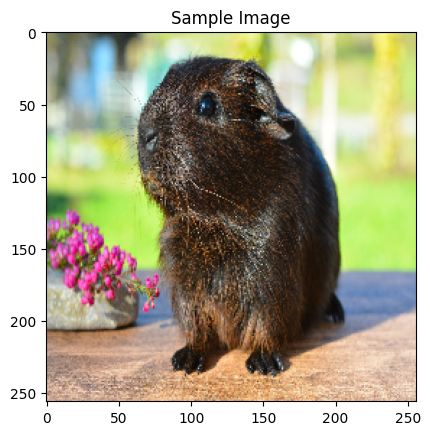

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Download datasets using kagglehub
# For DIV2K
path_div2k = '/kaggle/input/div2k-high-resolution-images'
print(f"DIV2K Dataset Path: {path_div2k}")

# Traverse subdirectories to get all image paths
def get_image_paths(dataset_path):
    image_paths = []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith(('jpg', 'png', 'jpeg')):  # Image file types
                image_paths.append(os.path.join(root, file))
    return image_paths

# Get image paths
train_image_paths = get_image_paths(os.path.join(path_div2k, 'DIV2K_train_HR'))
valid_image_paths = get_image_paths(os.path.join(path_div2k, 'DIV2K_valid_HR'))

print(f"Found {len(train_image_paths)} training images.")
print(f"Found {len(valid_image_paths)} validation images.")

# Define the dataset class
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
        print(f"Found {len(self.image_paths)} images in dataset")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]

        # Read the image
        image = cv2.imread(image_path)

        if image is None:
            raise ValueError(f"Failed to load image from {image_path}")

        # Convert to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize image
        image = cv2.resize(image, (256, 256))

        # Convert to tensor
        image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0

        return image

# Create dataset and dataloader for training
train_dataset = ImageDataset(train_image_paths)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Display a sample image from the dataset
def display_sample_image(dataloader):
    data_iter = iter(dataloader)
    sample_image = next(data_iter)

    # Convert the tensor back to numpy for displaying
    sample_image = sample_image[0].permute(1, 2, 0).numpy()

    plt.imshow(sample_image)
    plt.title('Sample Image')
    plt.show()

# Display a sample image from the training dataset
display_sample_image(train_dataloader)


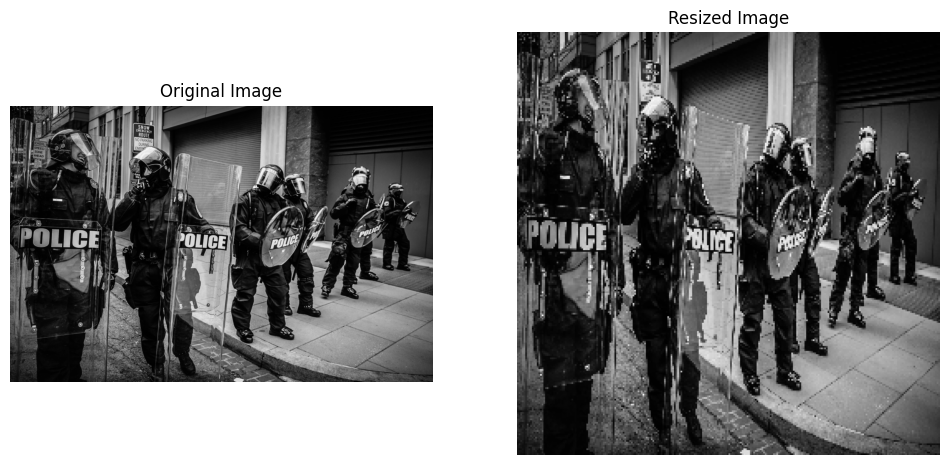

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Function to get image paths
def get_image_paths(dataset_path):
    image_paths = []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith(('jpg', 'png', 'jpeg')):  # Image file types
                image_paths.append(os.path.join(root, file))
    return image_paths

# Resize image to fixed size (e.g., 256x256)
def resize_image(image, target_size=(256, 256)):
    return cv2.resize(image, target_size)

# Dataset class
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None, target_size=(256, 256)):
        self.image_paths = image_paths
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]

        # Read image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image from {image_path}")

        # Convert to RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize image to fixed size
        image_resized = resize_image(image_rgb, self.target_size)

        # Convert to tensor and normalize (0-1 range)
        image_resized_tensor = torch.from_numpy(image_resized.transpose(2, 0, 1)).float() / 255.0

        return image_rgb, image_resized_tensor

# Collate function to ensure uniform batch shapes
def collate_fn(batch):
    images_rgb = [item[0] for item in batch]
    images_resized = [item[1] for item in batch]

    # Stack the images into a batch
    images_resized_batch = torch.stack(images_resized, dim=0)

    return images_rgb, images_resized_batch

# Load dataset and dataloaders
train_image_paths = get_image_paths('/kaggle/input/div2k-high-resolution-images/DIV2K_train_HR')
train_dataset = ImageDataset(train_image_paths)
train_dataloader = DataLoader(train_dataset, batch_size=16, collate_fn=collate_fn, shuffle=True)

# Function to display a sample image (original and resized)
def display_sample_image(dataloader):
    data_iter = iter(dataloader)
    sample_image_rgb, sample_image_resized = next(data_iter)

    # Plot original and resized images side by side
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Display original image (show the first image from the batch)
    ax[0].imshow(sample_image_rgb[0])
    ax[0].set_title('Original Image')
    ax[0].axis('off')  # Turn off axis

    # Display resized image (show the first image from the batch)
    sample_image_resized = sample_image_resized[0].permute(1, 2, 0).numpy()
    ax[1].imshow(sample_image_resized)
    ax[1].set_title('Resized Image')
    ax[1].axis('off')  # Turn off axis

    plt.show()

# Display a sample image from the training dataset (original and resized)
display_sample_image(train_dataloader)


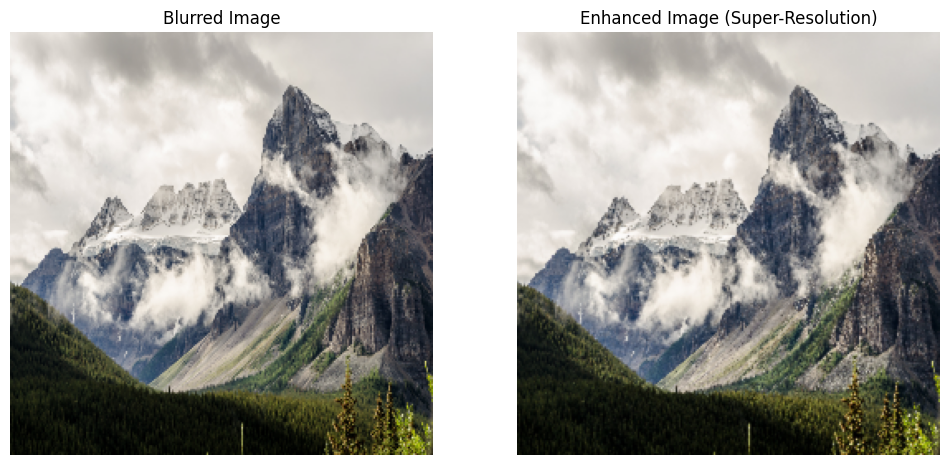

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import numpy as np

# Function to get image paths
def get_image_paths(dataset_path):
    image_paths = []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith(('jpg', 'png', 'jpeg')):  # Image file types
                image_paths.append(os.path.join(root, file))
    return image_paths

# Apply Gaussian blur to simulate low-quality (low bandwidth) image
def apply_gaussian_blur(image, kernel_size=(5, 5)):
    return cv2.GaussianBlur(image, kernel_size, 0)

# Load a pre-trained super-resolution model (for simplicity, let's use a basic upscale for now)
def super_resolve_image(image):
    # Example: Use OpenCV to upscale the image (nearest-neighbor interpolation for demo purposes)
    height, width, _ = image.shape
    new_dimensions = (width * 2, height * 2)  # Upscale by a factor of 2
    return cv2.resize(image, new_dimensions, interpolation=cv2.INTER_CUBIC)

# Dataset class
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None, target_size=(256, 256)):
        self.image_paths = image_paths
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]

        # Read image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image from {image_path}")

        # Convert to RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply Gaussian blur to simulate a low-quality image
        blurred_image = apply_gaussian_blur(image_rgb)

        # Resize image to simulate low-bandwidth conditions
        resized_image = cv2.resize(image_rgb, self.target_size)

        # Use super-resolution technique to enhance image clarity
        enhanced_image = super_resolve_image(resized_image)

        # Resize both blurred and enhanced images to the target size for consistency
        blurred_image_resized = cv2.resize(blurred_image, self.target_size)
        enhanced_image_resized = cv2.resize(enhanced_image, self.target_size)

        # Convert to tensor and normalize (0-1 range)
        blurred_image_tensor = torch.from_numpy(blurred_image_resized.transpose(2, 0, 1)).float() / 255.0
        enhanced_image_tensor = torch.from_numpy(enhanced_image_resized.transpose(2, 0, 1)).float() / 255.0

        return blurred_image, enhanced_image, blurred_image_tensor, enhanced_image_tensor

# Collate function to ensure uniform batch shapes
def collate_fn(batch):
    images_blurred = [item[2] for item in batch]
    images_enhanced = [item[3] for item in batch]

    # Stack the images into a batch
    images_blurred_batch = torch.stack(images_blurred, dim=0)
    images_enhanced_batch = torch.stack(images_enhanced, dim=0)

    return images_blurred_batch, images_enhanced_batch

# Load dataset and dataloaders
train_image_paths = get_image_paths('/kaggle/input/div2k-high-resolution-images/DIV2K_train_HR')
train_dataset = ImageDataset(train_image_paths)
train_dataloader = DataLoader(train_dataset, batch_size=16, collate_fn=collate_fn, shuffle=True)

# Function to display a sample image (blurred and enhanced)
def display_sample_image(dataloader):
    data_iter = iter(dataloader)
    sample_image_blurred, sample_image_enhanced = next(data_iter)

    # Plot blurred and enhanced images side by side
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Display blurred image (show the first image from the batch)
    ax[0].imshow(sample_image_blurred[0].permute(1, 2, 0).numpy())
    ax[0].set_title('Blurred Image')
    ax[0].axis('off')  # Turn off axis

    # Display enhanced image (show the first image from the batch)
    ax[1].imshow(sample_image_enhanced[0].permute(1, 2, 0).numpy())
    ax[1].set_title('Enhanced Image (Super-Resolution)')
    ax[1].axis('off')  # Turn off axis

    plt.show()

# Display a sample image from the training dataset (blurred and enhanced)
display_sample_image(train_dataloader)
